In [9]:
import os
import shutil

import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "video1.mp4"
NUM_FRAMES = 5
LABEL = "walking"          
IMG_SIZE = 128
BATCH_SIZE = 2

FRAMES_FOLDER = "frames"
DATASET_FOLDER = "dataset"
RESIZED_FOLDER = "resized_frames"


def show(images, titles):
    # OpenCV rasmlari BGR, matplotlib RGB kutadi, shuning uchun o'giramiz
    fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 4))
    axes = np.atleast_1d(axes)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 1. Video Loading



In [10]:
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise FileNotFoundError("Video ochilmadi. Fayl nomi va joylashuvini tekshiring: " + VIDEO_PATH)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Video ochildi")
print("Jami kadrlar :", total_frames)
print("FPS          :", round(fps, 2))
print("O'lcham      :", width, "x", height, "(width x height)")
print("Davomiylik   :", round(total_frames / fps, 1), "sekund")

Video ochildi
Jami kadrlar : 542
FPS          : 25.0
O'lcham      : 4096 x 2160 (width x height)
Davomiylik   : 21.7 sekund


## 2. Create Folder And Make Frames

Videodan **5 ta kadr** olamiz. Ular videoning boshidan oxirigacha **teng oraliqda** tanlanadi, shuning uchun bir-biridan farq qiladi.

- `cap.set(cv2.CAP_PROP_POS_FRAMES, pos)` kerakli kadrga sakraydi
- `cap.read()` shu kadrni o'qiydi
- `cv2.imwrite(...)` kadrni rasm fayl qilib saqlaydi

Papka tayyor: frames
Tanlangan kadr raqamlari: [0, 135, 270, 405, 540]
Saqlandi: frames/frame_001.jpg
Saqlandi: frames/frame_002.jpg
Saqlandi: frames/frame_003.jpg
Saqlandi: frames/frame_004.jpg
Saqlandi: frames/frame_005.jpg


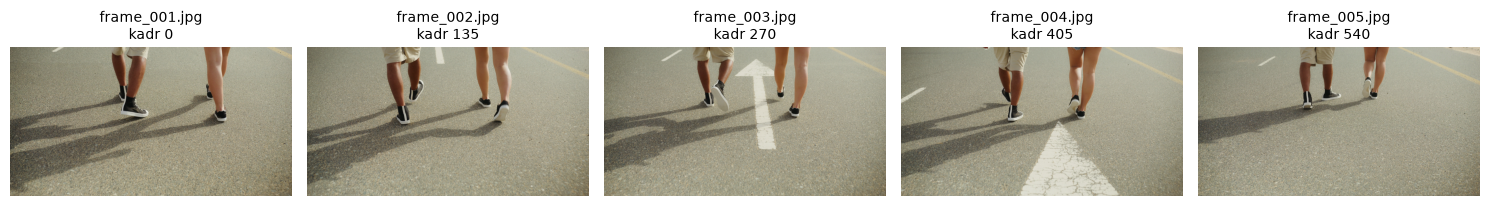

In [11]:
if os.path.exists(FRAMES_FOLDER):
    shutil.rmtree(FRAMES_FOLDER)             # eski kadrlarni tozalaymiz
os.makedirs(FRAMES_FOLDER, exist_ok=True)
print("Papka tayyor:", FRAMES_FOLDER)

frame_positions = np.linspace(0, total_frames - 2, NUM_FRAMES).astype(int).tolist()
print("Tanlangan kadr raqamlari:", frame_positions)

saved_names = []
saved_images = []

for i, pos in enumerate(frame_positions, start=1):
    cap.set(cv2.CAP_PROP_POS_FRAMES, pos)
    success, frame = cap.read()
    if success:
        frame_name = f"frame_{i:03d}.jpg"
        frame_path = os.path.join(FRAMES_FOLDER, frame_name)
        cv2.imwrite(frame_path, frame)
        saved_names.append(frame_name)
        saved_images.append(frame)
        print("Saqlandi:", frame_path)
    else:
        print("Kadrni o'qib bo'lmadi, raqami:", pos)

cap.release()

show(saved_images, [f"{n}\nkadr {p}" for n, p in zip(saved_names, frame_positions)])

## 3. Labeling

**Label** bu to'g'ri javob. Bizda **bitta video**, shuning uchun **hamma kadrga bir xil label** beramiz. Bu **Simple Labeling** deyiladi.

`labels` bu lug'at (dictionary): `kadr nomi -> label`.

In [12]:
labels = {}
for frame_name in saved_names:
    labels[frame_name] = LABEL

for frame_name, label in labels.items():
    print(frame_name, "->", label)

frame_001.jpg -> walking
frame_002.jpg -> walking
frame_003.jpg -> walking
frame_004.jpg -> walking
frame_005.jpg -> walking


## 4. Sample Labeling

Kadrlarni **label nomli papkaga** ko'chiramiz:

```
dataset/
└── walking/
    ├── frame_001.jpg
    ├── frame_002.jpg
    └── ...
```

Deep learning'da ma'lumotlar ko'pincha aynan shunday saqlanadi: **folder name = class name**. Bizda bitta video bo'lgani uchun faqat bitta folder chiqadi.

In [15]:
if os.path.exists(DATASET_FOLDER):
    shutil.rmtree(DATASET_FOLDER)

for frame_name, label in labels.items():
    class_path = os.path.join(DATASET_FOLDER, label)
    os.makedirs(class_path, exist_ok=True)

    source_path = os.path.join(FRAMES_FOLDER, frame_name)
    destination_path = os.path.join(class_path, frame_name)
    shutil.copy(source_path, destination_path)
    print(f"Copied: {frame_name} -> {label}/")

print("\nDataset:")
for label in os.listdir(DATASET_FOLDER):
    for img in sorted(os.listdir(os.path.join(DATASET_FOLDER, label))):
        print(" ", label, "/", img)

Copied: frame_001.jpg -> walking/
Copied: frame_002.jpg -> walking/
Copied: frame_003.jpg -> walking/
Copied: frame_004.jpg -> walking/
Copied: frame_005.jpg -> walking/

Dataset:
  walking / frame_001.jpg
  walking / frame_002.jpg
  walking / frame_003.jpg
  walking / frame_004.jpg
  walking / frame_005.jpg


## 5. Resizing Frames


frame_001.jpg: (2160, 4096, 3) -> (128, 128, 3)
frame_002.jpg: (2160, 4096, 3) -> (128, 128, 3)
frame_003.jpg: (2160, 4096, 3) -> (128, 128, 3)
frame_004.jpg: (2160, 4096, 3) -> (128, 128, 3)
frame_005.jpg: (2160, 4096, 3) -> (128, 128, 3)


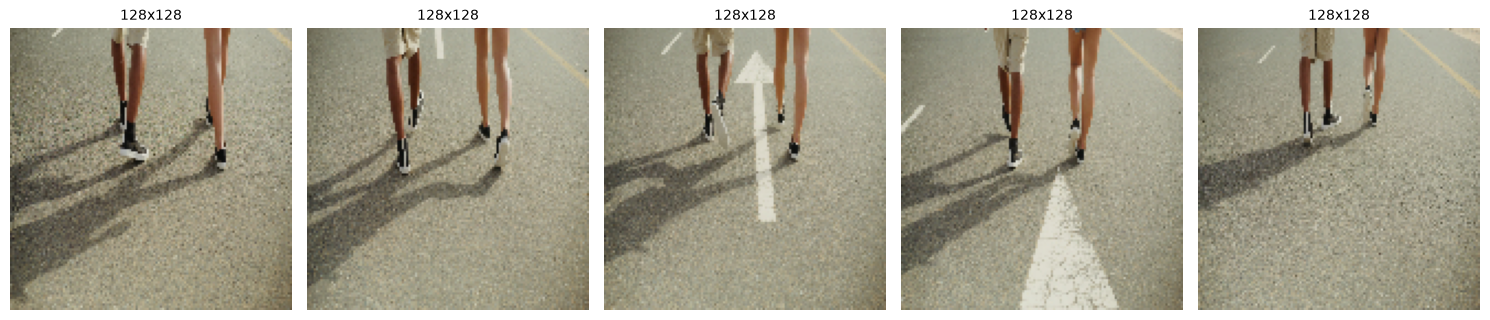

In [16]:
os.makedirs(RESIZED_FOLDER, exist_ok=True)

resized_frames = []

for frame_name in labels.keys():
    frame_path = os.path.join(FRAMES_FOLDER, frame_name)
    frame = cv2.imread(frame_path)

    if frame is not None:
        old_shape = frame.shape
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(os.path.join(RESIZED_FOLDER, frame_name), frame)
        resized_frames.append(frame)
        print(f"{frame_name}: {old_shape} -> {frame.shape}")
    else:
        print("Kadr topilmadi:", frame_path)

show(resized_frames, [f"{IMG_SIZE}x{IMG_SIZE}"] * len(resized_frames))

## 6. Frame Normalization

Piksellar **0 dan 255 gacha** butun sonlar. Modelga qulay bo'lishi uchun hammasini `255` ga bo'lib, **0 dan 1 gacha** oraliqqa keltiramiz.

```
yangi_qiymat = eski_qiymat / 255
```

Muhim: normallashtirilgan kadrni `.jpg` qilib saqlab bo'lmaydi, chunki `.jpg` faqat 0-255 butun sonlarni saqlaydi. Shuning uchun u **xotirada** (massiv sifatida) qoladi.

In [17]:
normalized_frames = []

for frame in resized_frames:
    frame = frame.astype(np.float32) / 255.0
    normalized_frames.append(frame)

before = resized_frames[0]
after = normalized_frames[0]

print("Normalizatsiyadan oldin:")
print("  dtype:", before.dtype, "| eng kichik:", before.min(), "| eng katta:", before.max())
print("Normalizatsiyadan keyin:")
print("  dtype:", after.dtype, "| eng kichik:", round(float(after.min()), 2), "| eng katta:", round(float(after.max()), 2))
print("\nShakl o'zgarmadi:", after.shape)

Normalizatsiyadan oldin:
  dtype: uint8 | eng kichik: 8 | eng katta: 227
Normalizatsiyadan keyin:
  dtype: float32 | eng kichik: 0.03 | eng katta: 0.89

Shakl o'zgarmadi: (128, 128, 3)


## 7. Batching Frames

**Batch** bu modelga bir vaqtda beriladigan bir nechta kadr to'plami.

Avval hamma kadrni bitta massivga yig'amiz: `(kadrlar soni, H, W, C)`. Keyin `BATCH_SIZE` tadan bo'laklarga bo'lamiz.

5 ta kadr va `BATCH_SIZE = 2` bo'lsa: **2 + 2 + 1** (oxirgi batch kichikroq chiqadi, bu normal).

In [18]:
all_frames = np.array(normalized_frames)
print("Hamma kadrlar shakli:", all_frames.shape, "(kadrlar, H, W, C)\n")

batches = []
for start in range(0, len(all_frames), BATCH_SIZE):
    batch = all_frames[start:start + BATCH_SIZE]
    batches.append(batch)
    print(f"Batch {len(batches)}: kadrlar {start + 1}-{start + len(batch)} | shakl = {batch.shape}")

print("\nJami batch soni:", len(batches))

Hamma kadrlar shakli: (5, 128, 128, 3) (kadrlar, H, W, C)

Batch 1: kadrlar 1-2 | shakl = (2, 128, 128, 3)
Batch 2: kadrlar 3-4 | shakl = (2, 128, 128, 3)
Batch 3: kadrlar 5-5 | shakl = (1, 128, 128, 3)

Jami batch soni: 3


## Xulosa

Ma'lumot shaklining bosqichma-bosqich o'zgarishi:

| Bosqich | Nima bo'ladi | Shakl |
|---|---|---|
| Video | Kadrlar ketma-ketligi | - |
| Kadr | Bitta rasm (`uint8`, 0-255) | `(height, width, 3)` |
| Resize | Hammasi bir xil o'lchamda | `(128, 128, 3)` |
| Normalization | Qiymatlar 0-1 oralig'ida (`float32`) | `(128, 128, 3)` |
| Hamma kadrlar | Bitta massivga yig'ildi | `(5, 128, 128, 3)` |
| Batch | Bo'laklarga bo'lindi | `(2, 128, 128, 3)` |

